# Hierarchical Rao PC-CNN Experiment — Tiny ImageNet 64×64

This notebook runs a balanced classification experiment with a hierarchical Rao-style predictive-coding model.

### Experiment subset

- **Classes:** 20
- **Training images per class:** 200
- **Validation images per class:** 50
- **Test images per class:** 50
- **Training images:** 4,000
- **Validation images:** 1,000
- **Test images:** 1,000
- **Input size:** 64×64 RGB

### Hierarchy

`64×64×3 image → 8×8 patches → r1: 8×8×32 → r2: 4×4×64 → r3: 256 → classifier`

The predictive hierarchy is trained with local prediction-error learning. Classification error is used only by the final readout and is not backpropagated through the predictive-coding hierarchy.


In [1]:
import os
import random
import time
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import src.data_cleaning_and_preprocessing._model_ready_dataset as model_ready_dataset
from src.dataset.tiny_imagenet_dataset import TinyImageNetLoader

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Device:", DEVICE)


Device: mps


## 1. Experiment configuration

These are the subset sizes you requested.


In [2]:
NUM_CLASSES = 5
TRAIN_IMAGES_PER_CLASS = 500
VAL_IMAGES_PER_CLASS = 50
TEST_IMAGES_PER_CLASS = 50

IMAGE_SIZE = 64
CHANNELS = 3

BATCH_SIZE = 32
NUM_EPOCHS = 100
PC_WARMUP_EPOCHS = 3

INFERENCE_STEPS = 30

PATCH_SIZE = 8
STRIDE = 8

R1_DIM = 32
R2_DIM = 64
R3_DIM = 256

STATE_LR = 0.05
STATE_DECAY = 0.001

PC_LR1 = 1e-4
PC_LR2 = 2e-4
PC_LR3 = 2e-4
CLASSIFIER_LR = 1e-3

STATE_CLIP = 5.0

print("Expected train images:", NUM_CLASSES * TRAIN_IMAGES_PER_CLASS)
print("Expected validation images:", NUM_CLASSES * VAL_IMAGES_PER_CLASS)
print("Expected test images:", NUM_CLASSES * TEST_IMAGES_PER_CLASS)


Expected train images: 2500
Expected validation images: 250
Expected test images: 250


## 2. Load your Tiny ImageNet dataset

This notebook expects three dataset objects:

```python
train_dataset
val_dataset
test_dataset
```

If you already have:

```python
cleaned_tiny_imagenet
```

with `(train, val, test)` inside it, run the next cell directly.

If your variable has another name, replace only the three assignment lines.


In [3]:
cleaned_tiny_imagenet = model_ready_dataset.ModelReadyDatasetLoader(
    TinyImageNetLoader(seed=SEED), image_size=64
).load()

train_dataset = cleaned_tiny_imagenet[0]
val_dataset = cleaned_tiny_imagenet[1]
test_dataset = cleaned_tiny_imagenet[2]

print("Full train dataset:", len(train_dataset))
print("Full validation dataset:", len(val_dataset))
print("Full test dataset:", len(test_dataset))


Full train dataset: 99953
Full validation dataset: 9993
Full test dataset: 9988


## 3. Helper functions for labels and class names

In [4]:
def get_base_dataset(dataset):
    base_dataset = getattr(dataset, "base_dataset", None)
    return base_dataset if base_dataset is not None else dataset


def get_label(dataset, index):
    item = dataset[index]
    return int(item[1])


def get_class_name_mapping(dataset):
    base_dataset = get_base_dataset(dataset)

    classes = getattr(base_dataset, "classes", None)
    idx_to_words = getattr(base_dataset, "idx_to_words", None)
    class_to_name = getattr(base_dataset, "class_to_name", None)

    mapping = {}

    if idx_to_words is not None:
        if isinstance(idx_to_words, dict):
            for key, value in idx_to_words.items():
                mapping[int(key)] = str(value)
        else:
            for i, value in enumerate(idx_to_words):
                mapping[i] = str(value)

    elif classes is not None:
        for i, value in enumerate(classes):
            if class_to_name is not None and value in class_to_name:
                mapping[i] = str(class_to_name[value])
            else:
                mapping[i] = str(value)

    return mapping


CLASS_NAME_MAPPING = get_class_name_mapping(train_dataset)

print("Class-name entries found:", len(CLASS_NAME_MAPPING))


Class-name entries found: 200


## 4. Select exactly 20 classes and balanced numbers of images

The notebook selects class IDs `0 ... 19` by default.

Each selected label is remapped to `0 ... 19`, which keeps the classifier output compact and consistent.


In [5]:
SELECTED_CLASSES = list(range(NUM_CLASSES))

print("Selected original class IDs:", SELECTED_CLASSES)


Selected original class IDs: [0, 1, 2, 3, 4]


In [6]:
class BalancedClassSubset(Dataset):

    def __init__(self, dataset, selected_classes, images_per_class, seed=42):
        self.dataset = dataset
        self.selected_classes = list(selected_classes)
        self.images_per_class = images_per_class
        self.original_to_new = {original_label: new_label for new_label, original_label in enumerate(self.selected_classes)}
        self.new_to_original = {new_label: original_label for original_label, new_label in self.original_to_new.items()}

        class_indices = defaultdict(list)

        for index in range(len(dataset)):
            label = get_label(dataset, index)

            if label in self.original_to_new:
                class_indices[label].append(index)

        rng = random.Random(seed)
        self.samples = []

        for original_label in self.selected_classes:
            available_indices = class_indices[original_label]

            if len(available_indices) < images_per_class:
                raise ValueError(f"Class {original_label} has only {len(available_indices)} images, but {images_per_class} were requested.")

            selected_indices = rng.sample(available_indices, images_per_class)
            new_label = self.original_to_new[original_label]

            for index in selected_indices:
                self.samples.append((index, new_label))

        rng.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        dataset_index, new_label = self.samples[index]
        image, _ = self.dataset[dataset_index]
        return image, new_label


In [7]:
train_subset = BalancedClassSubset(train_dataset, SELECTED_CLASSES, TRAIN_IMAGES_PER_CLASS, seed=SEED)
val_subset = BalancedClassSubset(val_dataset, SELECTED_CLASSES, VAL_IMAGES_PER_CLASS, seed=SEED + 1)
test_subset = val_subset #BalancedClassSubset(test_dataset, SELECTED_CLASSES, TEST_IMAGES_PER_CLASS, seed=SEED + 2)

print("Training subset:", len(train_subset))
print("Validation subset:", len(val_subset))
print("Test subset:", len(test_subset))


Training subset: 2500
Validation subset: 250
Test subset: 250


## 5. Verify balanced class counts

In [8]:
def count_subset_labels(dataset):
    counts = {class_id: 0 for class_id in range(NUM_CLASSES)}

    for _, label in dataset:
        counts[int(label)] += 1

    return counts


train_counts = count_subset_labels(train_subset)
val_counts = count_subset_labels(val_subset)
test_counts = count_subset_labels(test_subset)

counts_df = pd.DataFrame({
    "Class": list(range(NUM_CLASSES)),
    "Train": [train_counts[i] for i in range(NUM_CLASSES)],
    "Validation": [val_counts[i] for i in range(NUM_CLASSES)],
    "Test": [test_counts[i] for i in range(NUM_CLASSES)],
})

display(counts_df)


,Class,Train,Validation,Test
0,0,500,50,50
1,1,500,50,50
2,2,500,50,50
3,3,500,50,50
4,4,500,50,50


In [9]:
generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, generator=generator)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Training batches: 79
Validation batches: 8
Test batches: 8


## 6. Hierarchical Rao PC-CNN

Architecture:

- `U1`: local patch prediction
- `U2`: prediction of 2×2 groups of level-1 representations
- `U3`: prediction of the complete level-2 representation
- classifier: separate local readout from `r3`

There is no `loss.backward()` and no optimizer for `U1`, `U2`, or `U3`.


In [10]:
class HierarchicalRaoPCCNN:

    def __init__(self, input_shape=(3, 64, 64), patch_size=8, stride=8, r1_dim=32, r2_dim=64, r3_dim=256, num_classes=20, inference_steps=30, state_lr=0.05, state_decay=0.001, pc_lr1=1e-4, pc_lr2=2e-4, pc_lr3=2e-4, classifier_lr=1e-3, state_clip=5.0, device=None, seed=42):

        torch.manual_seed(seed)

        self.device = torch.device(device) if device is not None else DEVICE

        self.input_shape = input_shape
        self.patch_size = patch_size
        self.stride = stride
        self.r1_dim = r1_dim
        self.r2_dim = r2_dim
        self.r3_dim = r3_dim
        self.num_classes = num_classes
        self.inference_steps = inference_steps
        self.state_lr = state_lr
        self.state_decay = state_decay
        self.pc_lr1 = pc_lr1
        self.pc_lr2 = pc_lr2
        self.pc_lr3 = pc_lr3
        self.classifier_lr = classifier_lr
        self.state_clip = state_clip

        C, H, W = input_shape

        self.patch_h = (H - patch_size) // stride + 1
        self.patch_w = (W - patch_size) // stride + 1
        self.num_patches = self.patch_h * self.patch_w
        self.patch_dim = C * patch_size * patch_size

        if self.patch_h % 2 != 0 or self.patch_w % 2 != 0:
            raise ValueError("Patch grid must be divisible by 2.")

        self.r2_h = self.patch_h // 2
        self.r2_w = self.patch_w // 2
        self.num_regions = self.r2_h * self.r2_w
        self.r1_region_dim = 4 * r1_dim
        self.r2_flat_dim = self.num_regions * r2_dim

        self.U1 = torch.randn(self.num_patches, self.patch_dim, r1_dim, device=self.device) * 0.01
        self.U2 = torch.randn(self.num_regions, self.r1_region_dim, r2_dim, device=self.device) * 0.01
        self.U3 = torch.randn(self.r2_flat_dim, r3_dim, device=self.device) * 0.01

        self.W_class = torch.randn(num_classes, r3_dim, device=self.device) * 0.01
        self.b_class = torch.zeros(num_classes, device=self.device)

        self.normalize_weights()


    @torch.no_grad()
    def normalize_weights(self):

        eps = 1e-8

        self.U1 /= torch.linalg.vector_norm(self.U1, dim=1, keepdim=True).clamp_min(eps)
        self.U2 /= torch.linalg.vector_norm(self.U2, dim=1, keepdim=True).clamp_min(eps)
        self.U3 /= torch.linalg.vector_norm(self.U3, dim=0, keepdim=True).clamp_min(eps)


    @torch.no_grad()
    def extract_patches(self, images):

        images = images.to(self.device)
        patches = F.unfold(images, kernel_size=self.patch_size, stride=self.stride)
        patches = patches.transpose(1, 2)

        return patches


    @torch.no_grad()
    def group_r1(self, r1):

        B = r1.shape[0]

        x = r1.reshape(B, self.patch_h, self.patch_w, self.r1_dim)
        x = x.reshape(B, self.r2_h, 2, self.r2_w, 2, self.r1_dim)
        x = x.permute(0, 1, 3, 2, 4, 5).contiguous()
        x = x.reshape(B, self.num_regions, self.r1_region_dim)

        return x


    @torch.no_grad()
    def ungroup_r1(self, grouped):

        B = grouped.shape[0]

        x = grouped.reshape(B, self.r2_h, self.r2_w, 2, 2, self.r1_dim)
        x = x.permute(0, 1, 3, 2, 4, 5).contiguous()
        x = x.reshape(B, self.patch_h, self.patch_w, self.r1_dim)
        x = x.reshape(B, self.num_patches, self.r1_dim)

        return x


    @torch.no_grad()
    def initialize_states(self, patches):

        r1 = torch.einsum("pdh,bpd->bph", self.U1, patches)
        grouped_r1 = self.group_r1(r1)
        r2 = torch.einsum("pdh,bpd->bph", self.U2, grouped_r1)
        r2_flat = r2.reshape(r2.shape[0], -1)
        r3 = r2_flat @ self.U3

        return r1, r2, r3


    @torch.no_grad()
    def infer(self, images):

        patches = self.extract_patches(images)
        B = patches.shape[0]

        r1, r2, r3 = self.initialize_states(patches)

        for _ in range(self.inference_steps):

            pred_x = torch.einsum("pdh,bph->bpd", self.U1, r1)
            e0 = patches - pred_x

            grouped_r1 = self.group_r1(r1)
            pred_r1 = torch.einsum("pdh,bph->bpd", self.U2, r2)
            e1 = grouped_r1 - pred_r1

            r2_flat = r2.reshape(B, -1)
            pred_r2 = r3 @ self.U3.T
            e2 = r2_flat - pred_r2

            bottom_r1 = torch.einsum("pdh,bpd->bph", self.U1, e0)
            top_r1 = self.ungroup_r1(e1)
            dr1 = bottom_r1 - top_r1 - self.state_decay * r1

            bottom_r2 = torch.einsum("pdh,bpd->bph", self.U2, e1)
            top_r2 = e2.reshape(B, self.num_regions, self.r2_dim)
            dr2 = bottom_r2 - top_r2 - self.state_decay * r2

            bottom_r3 = e2 @ self.U3
            dr3 = bottom_r3 - self.state_decay * r3

            r1 = r1 + self.state_lr * dr1
            r2 = r2 + self.state_lr * dr2
            r3 = r3 + self.state_lr * dr3

            if self.state_clip is not None:
                r1 = r1.clamp(-self.state_clip, self.state_clip)
                r2 = r2.clamp(-self.state_clip, self.state_clip)
                r3 = r3.clamp(-self.state_clip, self.state_clip)

        pred_x = torch.einsum("pdh,bph->bpd", self.U1, r1)
        e0 = patches - pred_x

        grouped_r1 = self.group_r1(r1)
        pred_r1 = torch.einsum("pdh,bph->bpd", self.U2, r2)
        e1 = grouped_r1 - pred_r1

        r2_flat = r2.reshape(B, -1)
        pred_r2 = r3 @ self.U3.T
        e2 = r2_flat - pred_r2

        return {"patches": patches, "r1": r1, "r2": r2, "r3": r3, "pred_x": pred_x, "pred_r1": pred_r1, "pred_r2": pred_r2, "e0": e0, "e1": e1, "e2": e2}


    @torch.no_grad()
    def update_predictive_weights(self, result):

        r1 = result["r1"]
        r2 = result["r2"]
        r3 = result["r3"]

        e0 = result["e0"]
        e1 = result["e1"]
        e2 = result["e2"]

        B = r1.shape[0]

        dU1 = torch.einsum("bpd,bph->pdh", e0, r1) / B
        dU2 = torch.einsum("bpd,bph->pdh", e1, r2) / B
        dU3 = (e2.T @ r3) / B

        self.U1 += self.pc_lr1 * dU1
        self.U2 += self.pc_lr2 * dU2
        self.U3 += self.pc_lr3 * dU3

        self.normalize_weights()


    @torch.no_grad()
    def classifier_logits(self, r3):

        return r3 @ self.W_class.T + self.b_class


    @torch.no_grad()
    def update_classifier(self, r3, labels):

        labels = labels.to(self.device)
        B = labels.shape[0]

        logits = self.classifier_logits(r3)
        probabilities = torch.softmax(logits, dim=1)
        target = F.one_hot(labels, num_classes=self.num_classes).float()

        class_error = target - probabilities

        dW = (class_error.T @ r3) / B
        db = class_error.mean(dim=0)

        self.W_class += self.classifier_lr * dW
        self.b_class += self.classifier_lr * db

        predictions = logits.argmax(dim=1)
        accuracy = (predictions == labels).float().mean().item()

        eps = 1e-8
        classification_loss = -torch.log(probabilities[torch.arange(B, device=self.device), labels] + eps).mean().item()

        return {"accuracy": accuracy, "classification_loss": classification_loss}


    @torch.no_grad()
    def train_batch(self, images, labels, learn_predictive=True, learn_classifier=True):

        images = images.to(self.device)
        labels = labels.to(self.device)

        result = self.infer(images)

        if learn_predictive:
            self.update_predictive_weights(result)

        if learn_classifier:
            classifier_metrics = self.update_classifier(result["r3"], labels)
        else:
            logits = self.classifier_logits(result["r3"])
            probabilities = torch.softmax(logits, dim=1)
            predictions = logits.argmax(dim=1)
            accuracy = (predictions == labels).float().mean().item()
            eps = 1e-8
            classification_loss = -torch.log(probabilities[torch.arange(labels.shape[0], device=self.device), labels] + eps).mean().item()
            classifier_metrics = {"accuracy": accuracy, "classification_loss": classification_loss}

        error0 = result["e0"].square().mean().item()
        error1 = result["e1"].square().mean().item()
        error2 = result["e2"].square().mean().item()

        return {**classifier_metrics, "error_level_0": error0, "error_level_1": error1, "error_level_2": error2}


    @torch.no_grad()
    def predict(self, images):

        result = self.infer(images)
        logits = self.classifier_logits(result["r3"])
        probabilities = torch.softmax(logits, dim=1)
        predictions = probabilities.argmax(dim=1)

        return predictions, probabilities, result


    @torch.no_grad()
    def reconstruct_from_predicted_patches(self, pred_x):

        patches = pred_x.transpose(1, 2)
        reconstructed = F.fold(patches, output_size=(self.input_shape[1], self.input_shape[2]), kernel_size=self.patch_size, stride=self.stride)

        return reconstructed


    def architecture_summary(self):

        print("\nHIERARCHICAL RAO PC-CNN")
        print("=" * 60)
        print("Input shape:", self.input_shape)
        print("Patch size:", self.patch_size)
        print("Stride:", self.stride)
        print("Patch grid:", (self.patch_h, self.patch_w))
        print("Number of patches:", self.num_patches)
        print("Patch dimension:", self.patch_dim)
        print()
        print("r1:", (self.patch_h, self.patch_w, self.r1_dim))
        print("r2:", (self.r2_h, self.r2_w, self.r2_dim))
        print("r3:", self.r3_dim)
        print()
        print("U1:", tuple(self.U1.shape))
        print("U2:", tuple(self.U2.shape))
        print("U3:", tuple(self.U3.shape))
        print("Classifier:", tuple(self.W_class.shape))
        print("=" * 60)


    def state_dict(self):

        return {
            "U1": self.U1.detach().cpu(),
            "U2": self.U2.detach().cpu(),
            "U3": self.U3.detach().cpu(),
            "W_class": self.W_class.detach().cpu(),
            "b_class": self.b_class.detach().cpu(),
        }


    @torch.no_grad()
    def load_state_dict(self, state):

        self.U1.copy_(state["U1"].to(self.device))
        self.U2.copy_(state["U2"].to(self.device))
        self.U3.copy_(state["U3"].to(self.device))
        self.W_class.copy_(state["W_class"].to(self.device))
        self.b_class.copy_(state["b_class"].to(self.device))


## 7. Create the model

In [11]:
model = HierarchicalRaoPCCNN(input_shape=(3, IMAGE_SIZE, IMAGE_SIZE), patch_size=PATCH_SIZE, stride=STRIDE, r1_dim=R1_DIM, r2_dim=R2_DIM, r3_dim=R3_DIM, num_classes=NUM_CLASSES, inference_steps=INFERENCE_STEPS, state_lr=STATE_LR, state_decay=STATE_DECAY, pc_lr1=PC_LR1, pc_lr2=PC_LR2, pc_lr3=PC_LR3, classifier_lr=CLASSIFIER_LR, state_clip=STATE_CLIP, device=DEVICE, seed=SEED)

model.architecture_summary()



HIERARCHICAL RAO PC-CNN
Input shape: (3, 64, 64)
Patch size: 8
Stride: 8
Patch grid: (8, 8)
Number of patches: 64
Patch dimension: 192

r1: (8, 8, 32)
r2: (4, 4, 64)
r3: 256

U1: (64, 192, 32)
U2: (16, 128, 64)
U3: (1024, 256)
Classifier: (5, 256)


## 8. Evaluation helpers

Metrics are calculated without scikit-learn.


In [12]:
@torch.no_grad()
def evaluate_model(model, loader):

    total_correct = 0
    total_samples = 0
    total_loss = 0.0

    all_targets = []
    all_predictions = []
    all_probabilities = []

    eps = 1e-8

    for images, labels in loader:
        labels = labels.to(model.device)

        predictions, probabilities, _ = model.predict(images)

        batch_loss = -torch.log(probabilities[torch.arange(labels.shape[0], device=model.device), labels] + eps).mean()

        total_correct += (predictions == labels).sum().item()
        total_samples += labels.shape[0]
        total_loss += batch_loss.item() * labels.shape[0]

        all_targets.append(labels.cpu())
        all_predictions.append(predictions.cpu())
        all_probabilities.append(probabilities.cpu())

    targets = torch.cat(all_targets)
    predictions = torch.cat(all_predictions)
    probabilities = torch.cat(all_probabilities)

    accuracy = total_correct / total_samples
    loss = total_loss / total_samples

    return {"accuracy": accuracy, "loss": loss, "targets": targets, "predictions": predictions, "probabilities": probabilities}


In [13]:
def build_confusion_matrix(targets, predictions, num_classes):

    matrix = torch.zeros((num_classes, num_classes), dtype=torch.int64)

    for target, prediction in zip(targets, predictions):
        matrix[int(target), int(prediction)] += 1

    return matrix


def classification_report_from_confusion_matrix(matrix):

    rows = []

    for class_id in range(matrix.shape[0]):
        tp = matrix[class_id, class_id].item()
        fp = matrix[:, class_id].sum().item() - tp
        fn = matrix[class_id, :].sum().item() - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        original_class_id = SELECTED_CLASSES[class_id]
        class_name = CLASS_NAME_MAPPING.get(original_class_id, f"Class {original_class_id}")

        rows.append({
            "Class ID": class_id,
            "Original Class ID": original_class_id,
            "Class Name": class_name,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "Support": matrix[class_id, :].sum().item(),
        })

    return pd.DataFrame(rows)


## 9. Train the model

The first few epochs are predictive-coding warm-up epochs. During warm-up, the hierarchy learns generative structure while the classifier remains frozen.


In [14]:
from tqdm import tqdm

history = []

best_val_accuracy = -1.0
best_state = None

for epoch in tqdm(range(NUM_EPOCHS)):

    epoch_start = time.time()

    train_accuracy_sum = 0.0
    train_loss_sum = 0.0
    e0_sum = 0.0
    e1_sum = 0.0
    e2_sum = 0.0

    learn_classifier = epoch >= PC_WARMUP_EPOCHS

    for images, labels in train_loader:
        metrics = model.train_batch(images, labels, learn_predictive=True, learn_classifier=learn_classifier)

        train_accuracy_sum += metrics["accuracy"]
        train_loss_sum += metrics["classification_loss"]
        e0_sum += metrics["error_level_0"]
        e1_sum += metrics["error_level_1"]
        e2_sum += metrics["error_level_2"]

    train_accuracy = train_accuracy_sum / len(train_loader)
    train_loss = train_loss_sum / len(train_loader)
    e0 = e0_sum / len(train_loader)
    e1 = e1_sum / len(train_loader)
    e2 = e2_sum / len(train_loader)

    val_metrics = evaluate_model(model, val_loader)

    if val_metrics["accuracy"] > best_val_accuracy:
        best_val_accuracy = val_metrics["accuracy"]
        best_state = {key: value.clone() for key, value in model.state_dict().items()}

    epoch_seconds = time.time() - epoch_start

    history.append({
        "epoch": epoch + 1,
        "train_accuracy": train_accuracy,
        "train_loss": train_loss,
        "val_accuracy": val_metrics["accuracy"],
        "val_loss": val_metrics["loss"],
        "error_level_0": e0,
        "error_level_1": e1,
        "error_level_2": e2,
        "seconds": epoch_seconds,
    })

    print(f"Epoch {epoch + 1:03d}/{NUM_EPOCHS} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f} | E0: {e0:.6f} | E1: {e1:.6f} | E2: {e2:.6f} | {epoch_seconds:.1f}s")


  1%|          | 1/100 [00:01<02:22,  1.44s/it]

Epoch 001/100 | Train Acc: 0.2116 | Val Acc: 0.2120 | Train Loss: 1.6190 | Val Loss: 1.6384 | E0: 0.183849 | E1: 0.040616 | E2: 0.020088 | 1.4s


  2%|▏         | 2/100 [00:02<02:12,  1.36s/it]

Epoch 002/100 | Train Acc: 0.2093 | Val Acc: 0.2080 | Train Loss: 1.6445 | Val Loss: 1.6656 | E0: 0.168439 | E1: 0.036875 | E2: 0.010293 | 1.3s


  3%|▎         | 3/100 [00:04<02:09,  1.33s/it]

...

Epoch 098/100 | Train Acc: 0.5119 | Val Acc: 0.4320 | Train Loss: 1.2474 | Val Loss: 1.3836 | E0: 0.021630 | E1: 0.008152 | E2: 0.008512 | 2.7s


 99%|█████████▉| 99/100 [03:35<00:02,  2.36s/it]

Epoch 099/100 | Train Acc: 0.5059 | Val Acc: 0.4120 | Train Loss: 1.2406 | Val Loss: 1.3949 | E0: 0.021539 | E1: 0.008094 | E2: 0.008425 | 2.3s


100%|██████████| 100/100 [03:37<00:00,  2.18s/it]

Epoch 100/100 | Train Acc: 0.5123 | Val Acc: 0.3040 | Train Loss: 1.2401 | Val Loss: 1.5865 | E0: 0.021568 | E1: 0.008099 | E2: 0.008435 | 2.3s


## 10. Restore the best validation model

In [15]:
if best_state is not None:
    model.load_state_dict(best_state)

print("Best validation accuracy:", best_val_accuracy)


Best validation accuracy: 0.46


## 11. Plot learning curves

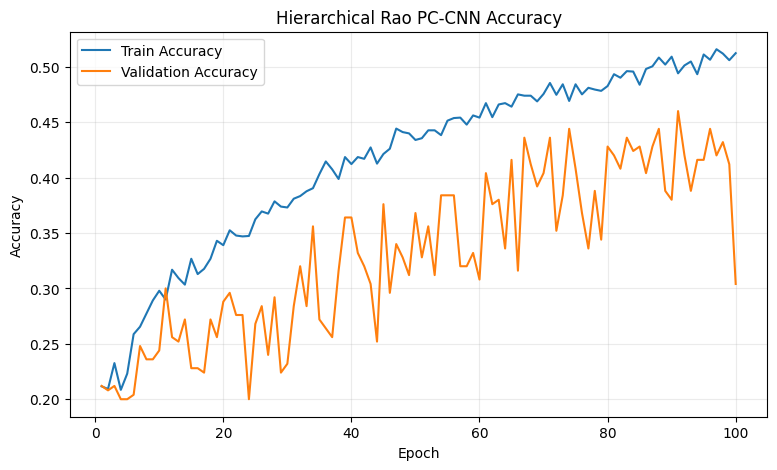

In [16]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Hierarchical Rao PC-CNN Accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


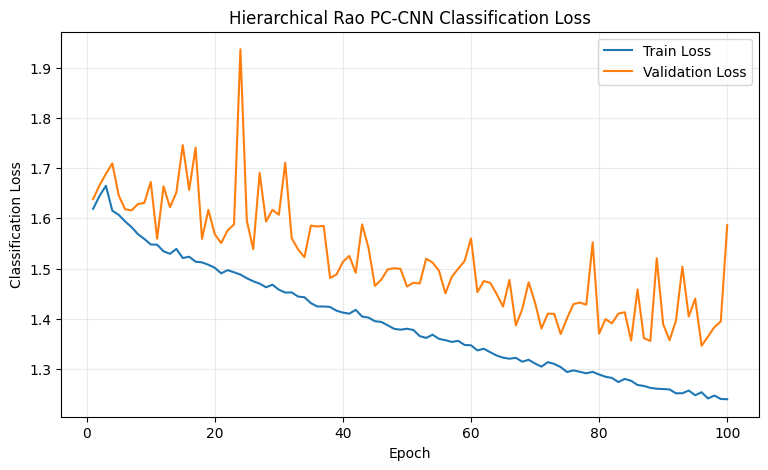

In [17]:
plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Classification Loss")
plt.title("Hierarchical Rao PC-CNN Classification Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


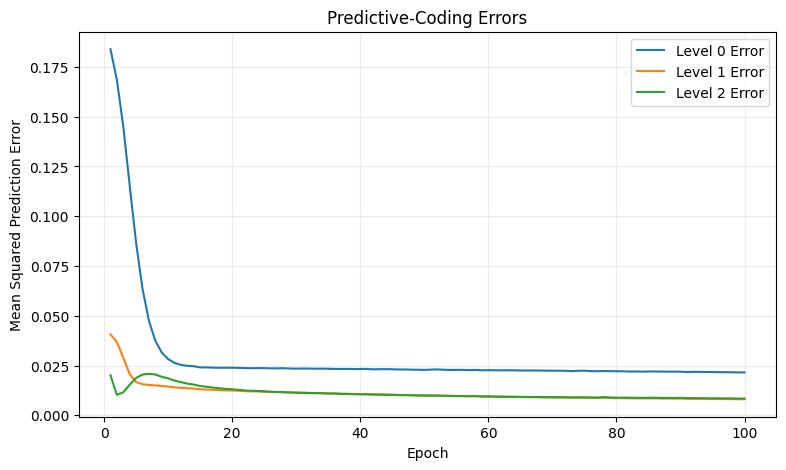

In [18]:
plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["error_level_0"], label="Level 0 Error")
plt.plot(history_df["epoch"], history_df["error_level_1"], label="Level 1 Error")
plt.plot(history_df["epoch"], history_df["error_level_2"], label="Level 2 Error")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Prediction Error")
plt.title("Predictive-Coding Errors")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 12. Final test evaluation

In [19]:
test_metrics = evaluate_model(model, test_loader)

print(f"Test Accuracy: {test_metrics['accuracy'] * 100:.2f}%")
print(f"Test Loss: {test_metrics['loss']:.6f}")


Test Accuracy: 46.00%
Test Loss: 1.357534


## 13. Confusion matrix

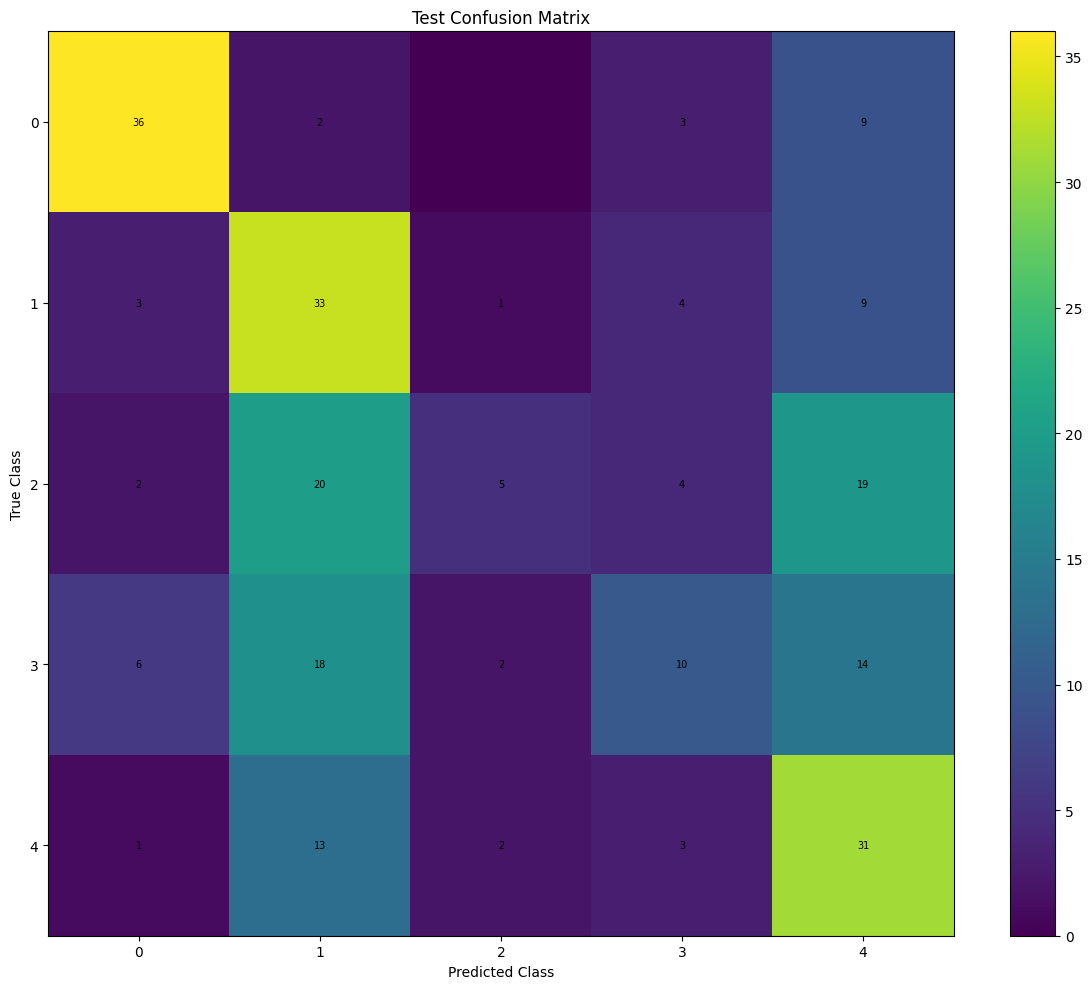

In [20]:
confusion_matrix = build_confusion_matrix(test_metrics["targets"], test_metrics["predictions"], NUM_CLASSES)

plt.figure(figsize=(12, 10))
plt.imshow(confusion_matrix.numpy(), interpolation="nearest", aspect="auto")
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(range(NUM_CLASSES))
plt.yticks(range(NUM_CLASSES))
plt.colorbar()

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        value = confusion_matrix[i, j].item()
        if value > 0:
            plt.text(j, i, str(value), ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()


## 14. Precision, recall, and F1-score

In [21]:
classification_df = classification_report_from_confusion_matrix(confusion_matrix)

display(classification_df)

print("Macro Precision:", classification_df["Precision"].mean())
print("Macro Recall:", classification_df["Recall"].mean())
print("Macro F1:", classification_df["F1"].mean())


,Class ID,Original Class ID,Class Name,Precision,Recall,F1,Support
0,0,0,"['goldfish', ' Carassius auratus']",0.750000,0.72,0.734694,50
1,1,1,"['European fire salamander', ' Salamandra sala...",0.383721,0.66,0.485294,50
2,2,2,"['bullfrog', ' Rana catesbeiana']",0.500000,0.10,0.166667,50
3,3,3,"['tailed frog', ' bell toad', ' ribbed toad', ...",0.416667,0.20,0.270270,50
4,4,4,"['American alligator', ' Alligator mississipie...",0.378049,0.62,0.469697,50


Macro Precision: 0.4856872754774059
Macro Recall: 0.45999999999999996
Macro F1: 0.4253243803663972


## 15. Five original vs reconstructed test images

The reconstruction shown here is produced from the final level-1 generative prediction after iterative predictive-coding inference.


In [22]:
def make_displayable(image):

    image = image.detach().cpu()

    image_min = image.amin(dim=(1, 2), keepdim=True)
    image_max = image.amax(dim=(1, 2), keepdim=True)

    image = (image - image_min) / (image_max - image_min + 1e-8)
    image = image.permute(1, 2, 0).numpy()

    return image


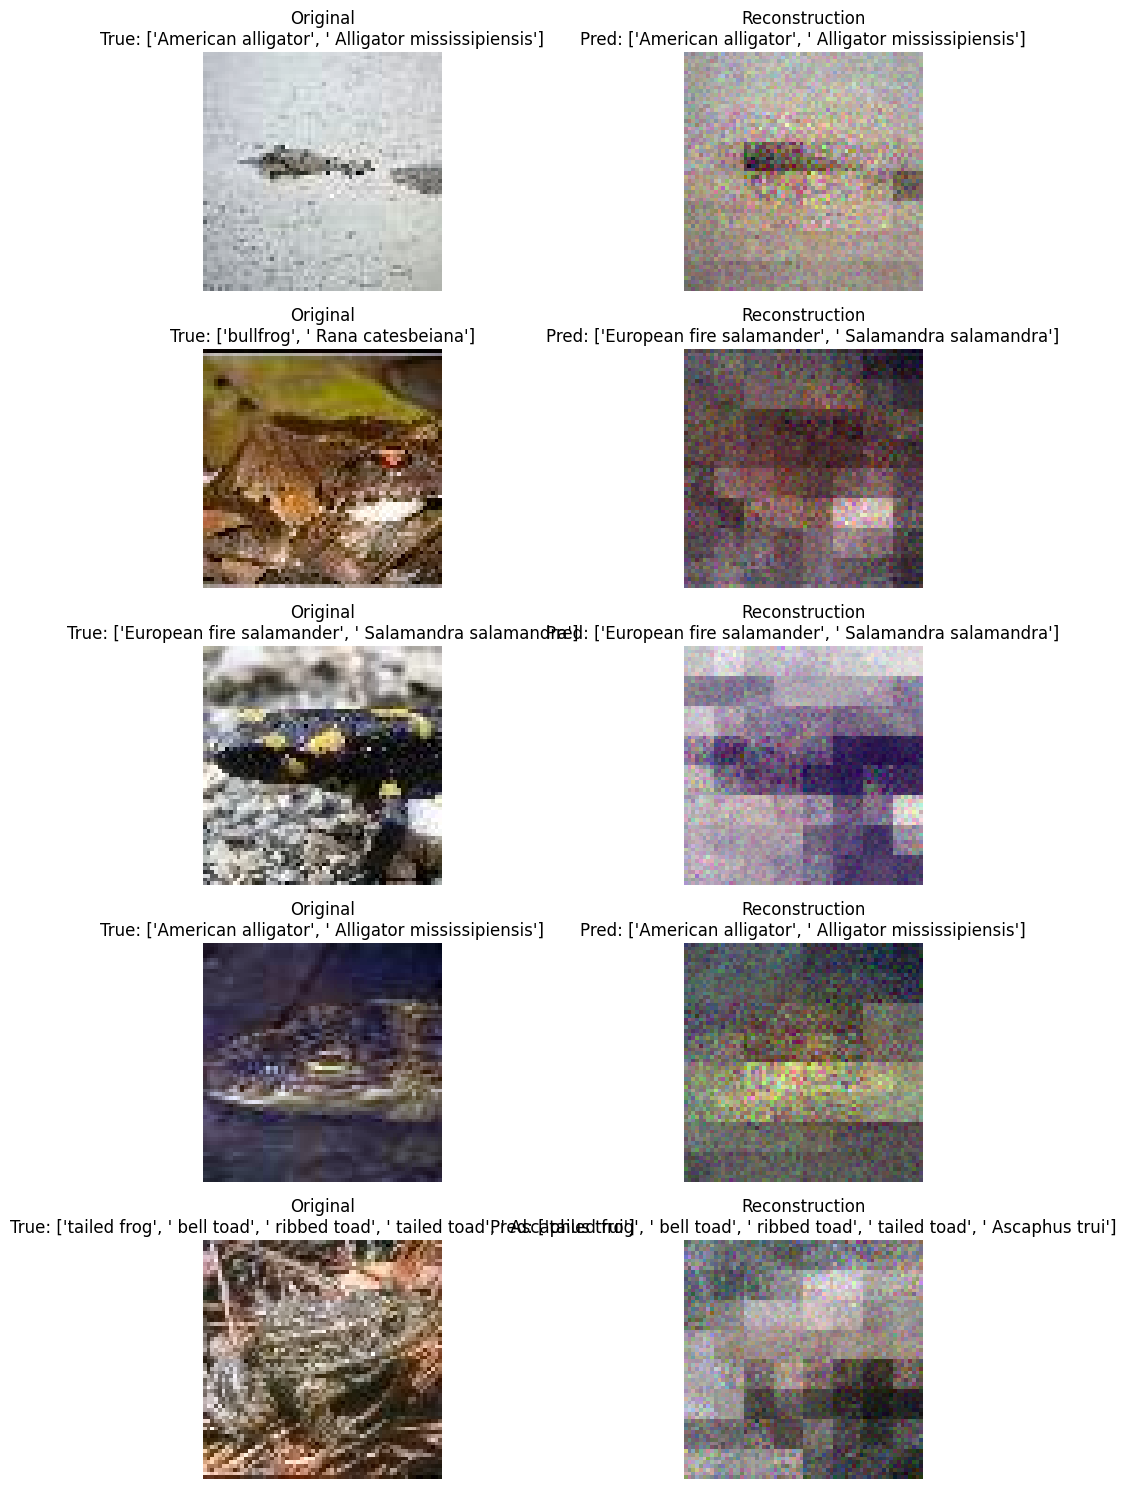

In [23]:
images, labels = next(iter(test_loader))

predictions, probabilities, result = model.predict(images)
reconstructed = model.reconstruct_from_predicted_patches(result["pred_x"])

num_images = min(5, images.shape[0])

plt.figure(figsize=(12, num_images * 3))

for i in range(num_images):

    true_original_id = SELECTED_CLASSES[int(labels[i])]
    pred_original_id = SELECTED_CLASSES[int(predictions[i].cpu())]

    true_name = CLASS_NAME_MAPPING.get(true_original_id, f"Class {true_original_id}")
    pred_name = CLASS_NAME_MAPPING.get(pred_original_id, f"Class {pred_original_id}")

    plt.subplot(num_images, 2, 2 * i + 1)
    plt.imshow(make_displayable(images[i]))
    plt.title(f"Original\nTrue: {true_name}")
    plt.axis("off")

    plt.subplot(num_images, 2, 2 * i + 2)
    plt.imshow(make_displayable(reconstructed[i]))
    plt.title(f"Reconstruction\nPred: {pred_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## 16. Save the trained model and experiment results

In [24]:
# MODEL_PATH = "hierarchical_rao_pccnn_tinyimagenet_20classes.pth"
# HISTORY_PATH = "hierarchical_rao_pccnn_history.csv"
# REPORT_PATH = "hierarchical_rao_pccnn_test_report.csv"
#
# checkpoint = {
#     "model_state": model.state_dict(),
#     "selected_classes": SELECTED_CLASSES,
#     "num_classes": NUM_CLASSES,
#     "input_shape": (3, IMAGE_SIZE, IMAGE_SIZE),
#     "patch_size": PATCH_SIZE,
#     "stride": STRIDE,
#     "r1_dim": R1_DIM,
#     "r2_dim": R2_DIM,
#     "r3_dim": R3_DIM,
#     "best_val_accuracy": best_val_accuracy,
#     "test_accuracy": test_metrics["accuracy"],
#     "test_loss": test_metrics["loss"],
# }
#
# torch.save(checkpoint, MODEL_PATH)
# history_df.to_csv(HISTORY_PATH, index=False)
# classification_df.to_csv(REPORT_PATH, index=False)
#
# print("Saved:", MODEL_PATH)
# print("Saved:", HISTORY_PATH)
# print("Saved:", REPORT_PATH)


## 17. Experiment summary

In [25]:
summary = pd.DataFrame({
    "Setting": [
        "Classes",
        "Train images per class",
        "Validation images per class",
        "Test images per class",
        "Total training images",
        "Total validation images",
        "Total test images",
        "Input size",
        "Patch size",
        "r1 dimension",
        "r2 dimension",
        "r3 dimension",
        "Best validation accuracy",
        "Test accuracy",
        "Test loss",
    ],
    "Value": [
        NUM_CLASSES,
        TRAIN_IMAGES_PER_CLASS,
        VAL_IMAGES_PER_CLASS,
        TEST_IMAGES_PER_CLASS,
        len(train_subset),
        len(val_subset),
        len(test_subset),
        f"{IMAGE_SIZE}x{IMAGE_SIZE}",
        PATCH_SIZE,
        R1_DIM,
        R2_DIM,
        R3_DIM,
        best_val_accuracy,
        test_metrics["accuracy"],
        test_metrics["loss"],
    ],
})

display(summary)


,Setting,Value
0,Classes,5
1,Train images per class,500
2,Validation images per class,50
3,Test images per class,50
4,Total training images,2500
5,Total validation images,250
6,Total test images,250
7,Input size,64x64
8,Patch size,8
9,r1 dimension,32


In [26]:
# MEAN = torch.tensor(train_dataset.mean).view(3, 1, 1)
# STD = torch.tensor(train_dataset.std).view(3, 1, 1)


def to_display_image(image):

    image = image.detach().cpu()
    # image = image * STD + MEAN
    image = image.clamp(0, 1)

    return image.permute(1, 2, 0).numpy()

In [70]:
IMAGE_INDEX = 100

image, label = test_subset[IMAGE_INDEX]

image_batch = image.unsqueeze(0)

predictions, probabilities, result = model.predict(image_batch)

r1 = result["r1"][0].detach().cpu()

print("Raw r1 shape:", r1.shape)

r1_maps = r1.reshape(model.patch_h, model.patch_w, model.r1_dim)

print("Spatial r1 shape:", r1_maps.shape)

Raw r1 shape: torch.Size([64, 32])
Spatial r1 shape: torch.Size([8, 8, 32])


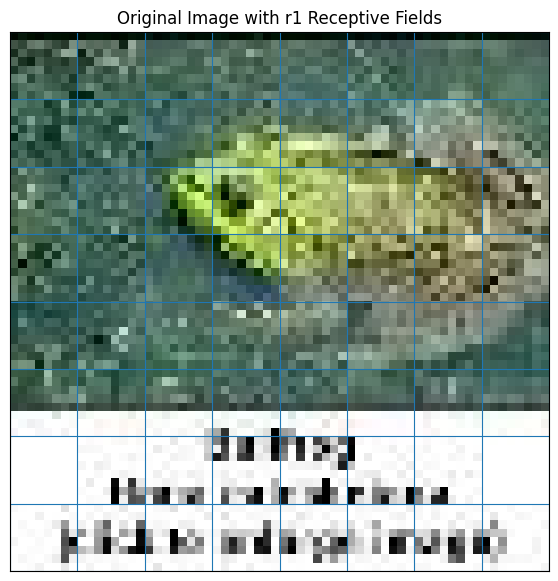

In [71]:
display_image = to_display_image(image)

plt.figure(figsize=(7, 7))
plt.imshow(display_image)

for x in range(0, IMAGE_SIZE + 1, PATCH_SIZE):
    plt.axvline(x - 0.5, linewidth=0.8)

for y in range(0, IMAGE_SIZE + 1, PATCH_SIZE):
    plt.axhline(y - 0.5, linewidth=0.8)

plt.title("Original Image with r1 Receptive Fields")
plt.xticks([])
plt.yticks([])
plt.show()

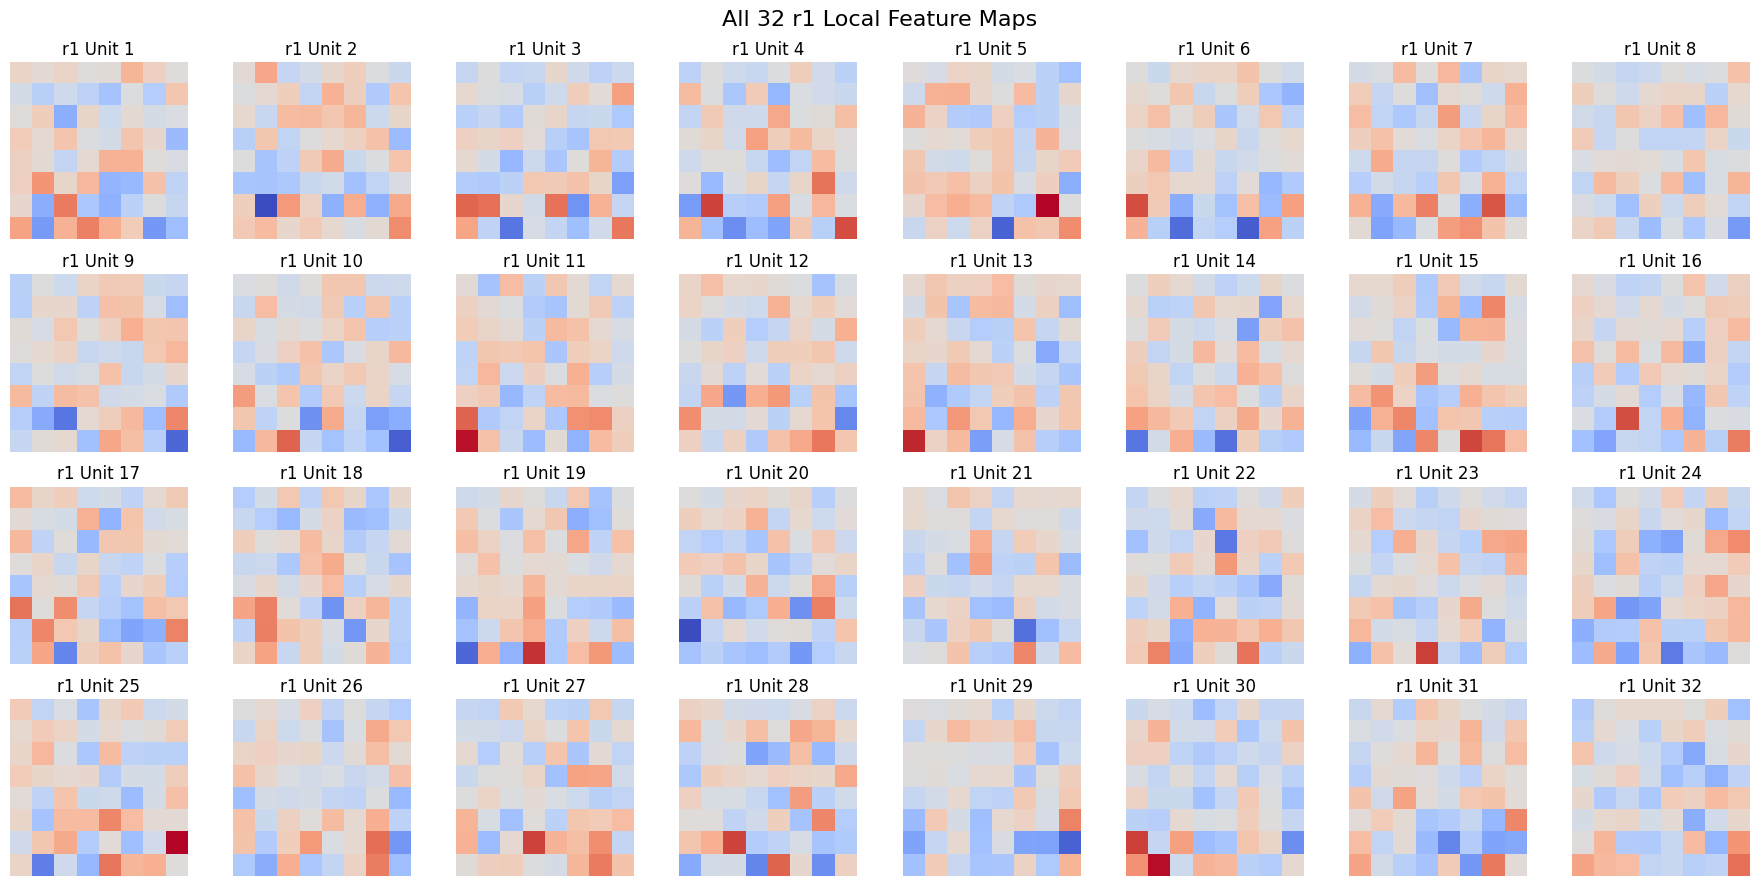

In [72]:
r1_numpy = r1_maps.numpy()

max_abs = np.abs(r1_numpy).max()

fig, axes = plt.subplots(4, 8, figsize=(18, 9))

for unit in range(model.r1_dim):

    ax = axes.flat[unit]

    activation_map = r1_numpy[:, :, unit]

    im = ax.imshow(activation_map, vmin=-max_abs, vmax=max_abs, cmap="coolwarm")

    ax.set_title(f"r1 Unit {unit + 1}")
    ax.axis("off")

plt.suptitle("All 32 r1 Local Feature Maps", fontsize=16)
plt.tight_layout()
plt.show()

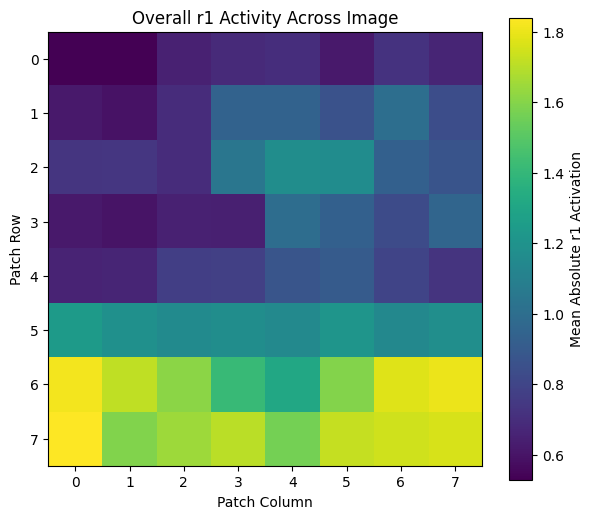

In [73]:
r1_strength = r1_maps.abs().mean(dim=2).numpy()

plt.figure(figsize=(7, 6))
plt.imshow(r1_strength, cmap="viridis")
plt.colorbar(label="Mean Absolute r1 Activation")
plt.title("Overall r1 Activity Across Image")
plt.xlabel("Patch Column")
plt.ylabel("Patch Row")
plt.xticks(range(model.patch_w))
plt.yticks(range(model.patch_h))
plt.show()

In [74]:
unit_strength = r1_maps.abs().mean(dim=(0, 1))

sorted_strength, sorted_indices = torch.sort(unit_strength, descending=True)

print("Strongest r1 units:\n")

for rank in range(model.r1_dim):
    unit = int(sorted_indices[rank])
    strength = float(sorted_strength[rank])

    print(f"{rank + 1:02d}. Unit {unit + 1:02d} | Mean activation: {strength:.6f}")

Strongest r1 units:

01. Unit 24 | Mean activation: 1.206297
02. Unit 03 | Mean activation: 1.172218
03. Unit 13 | Mean activation: 1.157889
04. Unit 15 | Mean activation: 1.157717
05. Unit 28 | Mean activation: 1.151805
06. Unit 17 | Mean activation: 1.146272
07. Unit 07 | Mean activation: 1.140075
08. Unit 11 | Mean activation: 1.128857
09. Unit 04 | Mean activation: 1.124533
10. Unit 01 | Mean activation: 1.122239
11. Unit 02 | Mean activation: 1.113484
12. Unit 19 | Mean activation: 1.101861
13. Unit 10 | Mean activation: 1.092287
14. Unit 18 | Mean activation: 1.079411
15. Unit 30 | Mean activation: 1.077909
16. Unit 20 | Mean activation: 1.069107
17. Unit 22 | Mean activation: 1.063501
18. Unit 25 | Mean activation: 1.062643
19. Unit 09 | Mean activation: 1.037657
20. Unit 05 | Mean activation: 1.036900
21. Unit 06 | Mean activation: 1.033617
22. Unit 31 | Mean activation: 1.030077
23. Unit 14 | Mean activation: 1.002279
24. Unit 26 | Mean activation: 0.987860
25. Unit 12 | Mean 

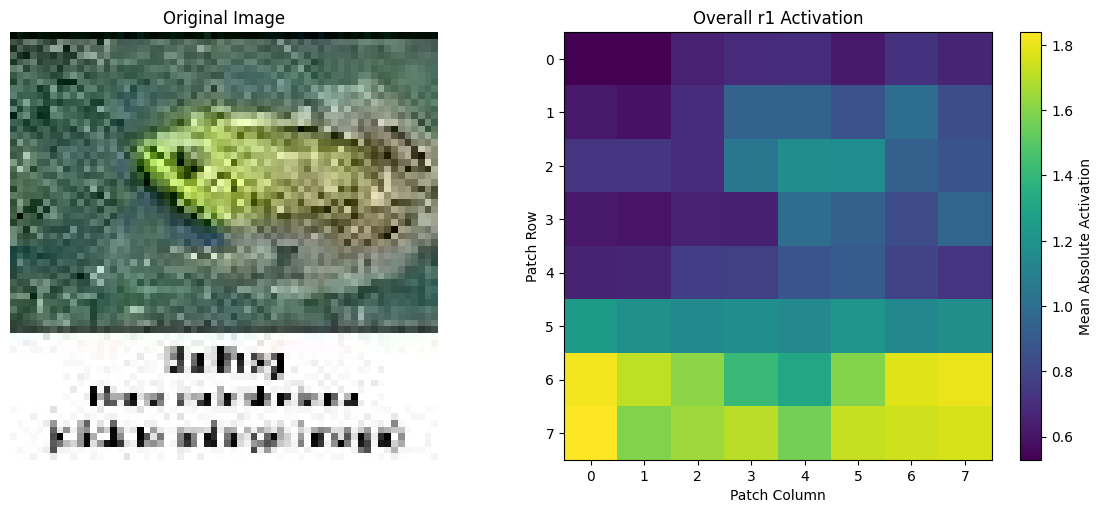

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(to_display_image(image))
axes[0].set_title("Original Image")
axes[0].axis("off")

im = axes[1].imshow(r1_strength, cmap="viridis")
axes[1].set_title("Overall r1 Activation")
axes[1].set_xlabel("Patch Column")
axes[1].set_ylabel("Patch Row")

plt.colorbar(im, ax=axes[1], label="Mean Absolute Activation")

plt.tight_layout()
plt.show()

In [76]:
# lable = test_subset[100]
true_original_class = SELECTED_CLASSES[int(label)]
predicted_class = int(predictions[0].cpu())
predicted_original_class = SELECTED_CLASSES[predicted_class]

true_name = CLASS_NAME_MAPPING.get(true_original_class, f"Class {true_original_class}")
predicted_name = CLASS_NAME_MAPPING.get(predicted_original_class, f"Class {predicted_original_class}")

confidence = probabilities[0, predicted_class].item()

print("True class:", true_name)
print("Predicted class:", predicted_name)
print(f"Prediction confidence: {confidence:.4f}")

True class: ['bullfrog', ' Rana catesbeiana']
Predicted class: ['European fire salamander', ' Salamandra salamandra']
Prediction confidence: 0.3426
